In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

import pandas as pd
import seaborn as sns

file_path = "/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv" 
df = pd.read_csv(file_path)
print(df.head())

#sns.countplot(df[])
#df['Estimated_Deliveries'].value_counts().plot(kind='bar')
df['Model'].value_counts().plot(kind='bar')

sns.distplot(df['Production_Units'])


oe = OrdinalEncoder(categories=[[ 'Europe', 'Asia', 'Middle East','North America' ],['Model Y', 'Model X', 'Model 3','Model S','Cybertruck' ]])


oe.fit(X_train)

X_train = oe. transform(X_train)

X_train










In [114]:
# IMPORT LIBRARIES


# Numerical & Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Plot Style
sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [115]:
# LOAD DATASET

file_path = "/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully.")

Dataset Loaded Successfully.


In [116]:
# BASIC DATA EXPLORATION

# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# First 5 rows
print("\nFirst 5 Rows:")
display(df.head())

# Last 5 rows
print("\nLast 5 Rows:")
display(df.tail())

# Dataset Information
print("\nDataset Info:")
print(df.info())

# Statistical Summary
print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (2640, 12)

Columns:
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

First 5 Rows:


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722



Last 5 Rows:


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
2635,2021,10,Middle East,Model Y,13488,14333,113771.10,120,719,1454.68,Official (Quarter),4273
2636,2019,7,Middle East,Model S,18300,18407,81889.67,82,487,1336.81,Official (Quarter),9833
2637,2019,9,Asia,Model S,13291,14839,97139.38,100,580,1156.32,Estimated (Region),13709
2638,2020,5,Asia,Cybertruck,3471,3714,69990.57,60,358,186.39,Interpolated (Month),6754
2639,2018,8,North America,Model S,2639,2929,51676.24,82,474,187.63,Estimated (Region),14297



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None

Statistical Summary:


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [117]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [118]:
# DUPLICATE VALUES

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [119]:
# DATA CLEANING

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Fill numerical missing values
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical missing values
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Data Cleaning Completed.")

Data Cleaning Completed.


In [120]:
df.columns
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [121]:
print(df.dtypes)

Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object


In [122]:

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


Region
['Europe' 'Asia' 'North America' 'Middle East']

Model
['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck']

Source_Type
['Interpolated (Month)' 'Official (Quarter)' 'Estimated (Region)']


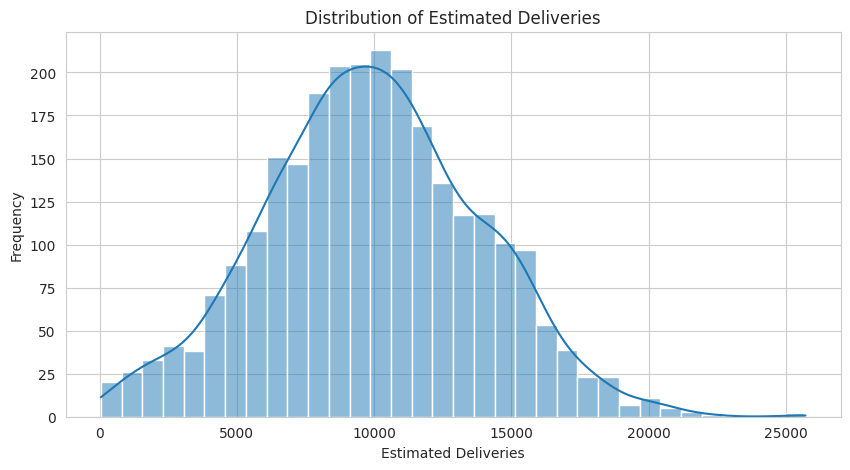

In [123]:

plt.figure(figsize=(10,5))

sns.histplot(df['Estimated_Deliveries'], kde=True)

plt.title("Distribution of Estimated Deliveries")
plt.xlabel("Estimated Deliveries")
plt.ylabel("Frequency")

plt.show()

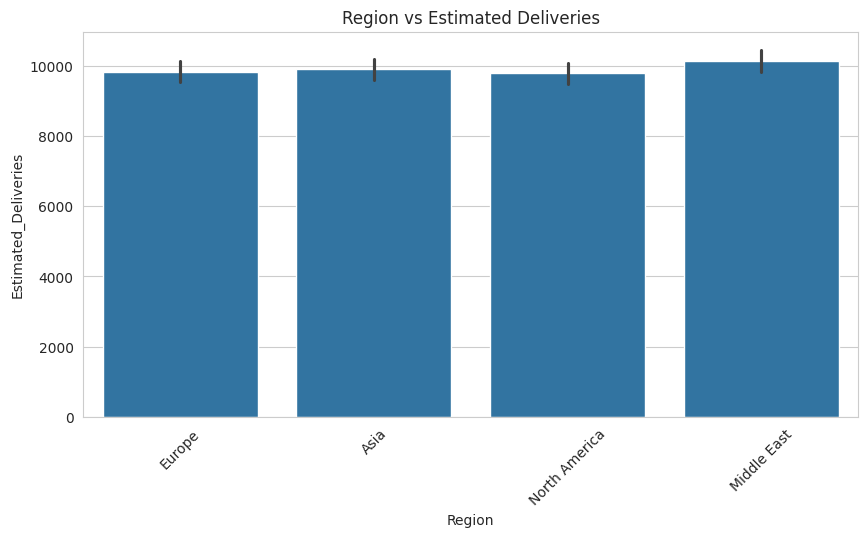

In [124]:

plt.figure(figsize=(10,5))

sns.barplot(
    x='Region',
    y='Estimated_Deliveries',
    data=df
)

plt.title("Region vs Estimated Deliveries")

plt.xticks(rotation=45)

plt.show()

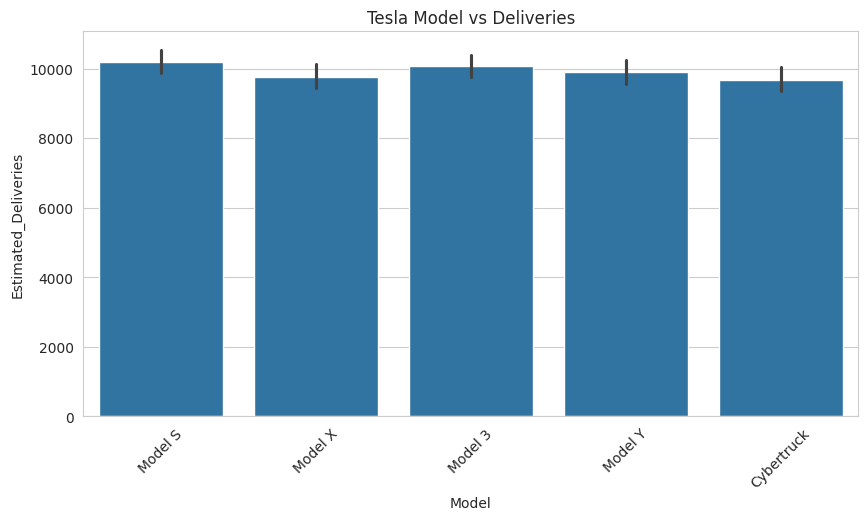

In [125]:

plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='Estimated_Deliveries',
    data=df
)

plt.title("Tesla Model vs Deliveries")

plt.xticks(rotation=45)

plt.show()

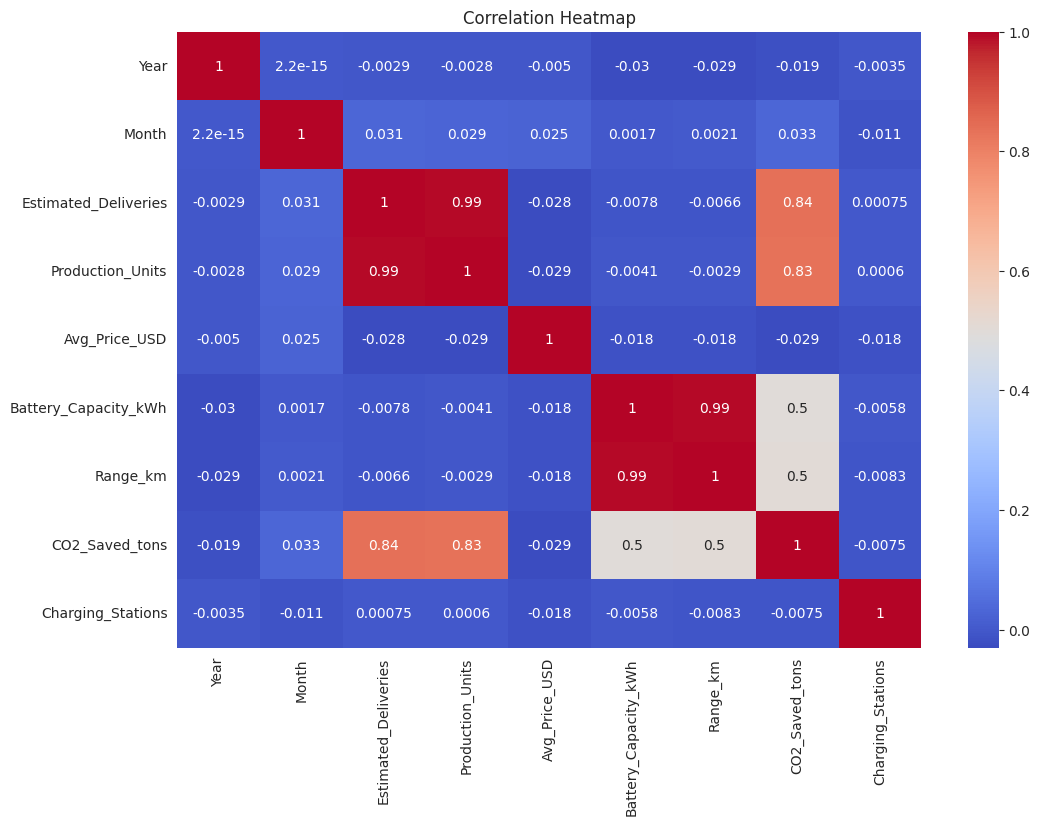

In [126]:

plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [127]:
# Create Date Column

df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' + df['Month'].astype(str)
)

print(df[['Year', 'Month', 'Date']].head())

   Year  Month       Date
0  2023      5 2023-05-01
1  2015      2 2015-02-01
2  2019      1 2019-01-01
3  2021      2 2021-02-01
4  2016     12 2016-12-01


In [128]:
df['Delivery_Efficiency'] = (
    df['Estimated_Deliveries'] / df['Production_Units']
)

df['Delivery_Efficiency'] = df['Delivery_Efficiency'].round(2)

display(df[['Estimated_Deliveries',
            'Production_Units',
            'Delivery_Efficiency']].head())

,Estimated_Deliveries,Production_Units,Delivery_Efficiency
0,17646,17922,0.98
1,3797,4164,0.91
2,8411,9189,0.92
3,6555,7311,0.90
4,12374,13537,0.91


In [129]:


df['Delivery_Efficiency'] = (
    df['Estimated_Deliveries'] / df['Production_Units']
)

df['Delivery_Efficiency'] = df['Delivery_Efficiency'].round(2)

display(df[['Estimated_Deliveries',
            'Production_Units',
            'Delivery_Efficiency']].head())

,Estimated_Deliveries,Production_Units,Delivery_Efficiency
0,17646,17922,0.98
1,3797,4164,0.91
2,8411,9189,0.92
3,6555,7311,0.90
4,12374,13537,0.91


In [130]:
df['Price_Per_KM'] = (
    df['Avg_Price_USD'] / df['Range_km']
)

display(df[['Avg_Price_USD',
            'Range_km',
            'Price_Per_KM']].head())

,Avg_Price_USD,Range_km,Price_Per_KM
0,92874.27,704,131.923679
1,62205.65,438,142.022032
2,117887.32,480,245.598583
3,89294.91,712,125.414199
4,114846.78,661,173.747020


In [131]:

df['Stations_Per_Delivery'] = (
    df['Charging_Stations'] / df['Estimated_Deliveries']
)

display(df[['Charging_Stations',
            'Estimated_Deliveries',
            'Stations_Per_Delivery']].head())

,Charging_Stations,Estimated_Deliveries,Stations_Per_Delivery
0,12207,17646,0.691772
1,7640,3797,2.012115
2,14071,8411,1.672928
3,9333,6555,1.423799
4,8722,12374,0.704865


In [132]:
target = 'Estimated_Deliveries'

In [133]:
X = df.drop(columns=[target, 'Date'])

y = df[target]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (2640, 14)
Target Shape: (2640,)


In [134]:
categorical_features = X.select_dtypes(include='object').columns

numerical_features = X.select_dtypes(include=np.number).columns

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
Index(['Region', 'Model', 'Source_Type'], dtype='object')

Numerical Features:
Index(['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations', 'Delivery_Efficiency', 'Price_Per_KM',
       'Stations_Per_Delivery'],
      dtype='object')


In [135]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (2112, 14)
Testing Shape: (528, 14)


In [136]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)

In [137]:
rf_pipeline = Pipeline(steps=[
    
    ('preprocessor', preprocessor),
    
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

print("Pipeline Created Successfully.")

Pipeline Created Successfully.


In [138]:
rf_pipeline.fit(X_train, y_train)

print("Model Training Completed.")

Model Training Completed.


In [139]:
y_pred = rf_pipeline.predict(X_test)

print(y_pred[:5])

[7040.77 9406.39 9123.15 8970.   8650.78]


In [140]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")

print(f"MSE  : {mse:.2f}")

print(f"RMSE : {rmse:.2f}")

print(f"R2 Score : {r2:.4f}")

MAE  : 79.46
MSE  : 15089.03
RMSE : 122.84
R2 Score : 0.9990


In [141]:
param_grid = {
    
    'model__n_estimators': [50, 100],
    
    'model__max_depth': [5, 10, None],
    
    'model__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    
    rf_pipeline,
    
    param_grid,
    
    cv=3,
    
    scoring='r2',
    
    n_jobs=-1,
    
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest R2 Score:")
print(grid_search.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters:
{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 50}

Best R2 Score:
0.9978962551408895


In [143]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

In [144]:
mae = mean_absolute_error(y_test, y_pred_best)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))

r2 = r2_score(y_test, y_pred_best)

print(f"MAE  : {mae:.2f}")

print(f"RMSE : {rmse:.2f}")

print(f"R2 Score : {r2:.4f}")

MAE  : 79.95
RMSE : 123.81
R2 Score : 0.9990


In [145]:

encoded_features = best_model.named_steps[
    'preprocessor'
].get_feature_names_out()

feature_names = list(encoded_features)

In [146]:
importances = best_model.named_steps[
    'model'
].feature_importances_

feature_importance_df = pd.DataFrame({
    
    'Feature': feature_names,
    
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

display(feature_importance_df.head(10))

,Feature,Importance
14,remainder__Production_Units,0.990435
20,remainder__Delivery_Efficiency,0.008254
18,remainder__CO2_Saved_tons,0.000191
21,remainder__Price_Per_KM,0.000188
13,remainder__Month,0.000178
22,remainder__Stations_Per_Delivery,0.000163
15,remainder__Avg_Price_USD,0.000140
17,remainder__Range_km,0.000094
12,remainder__Year,0.000089
19,remainder__Charging_Stations,0.000063


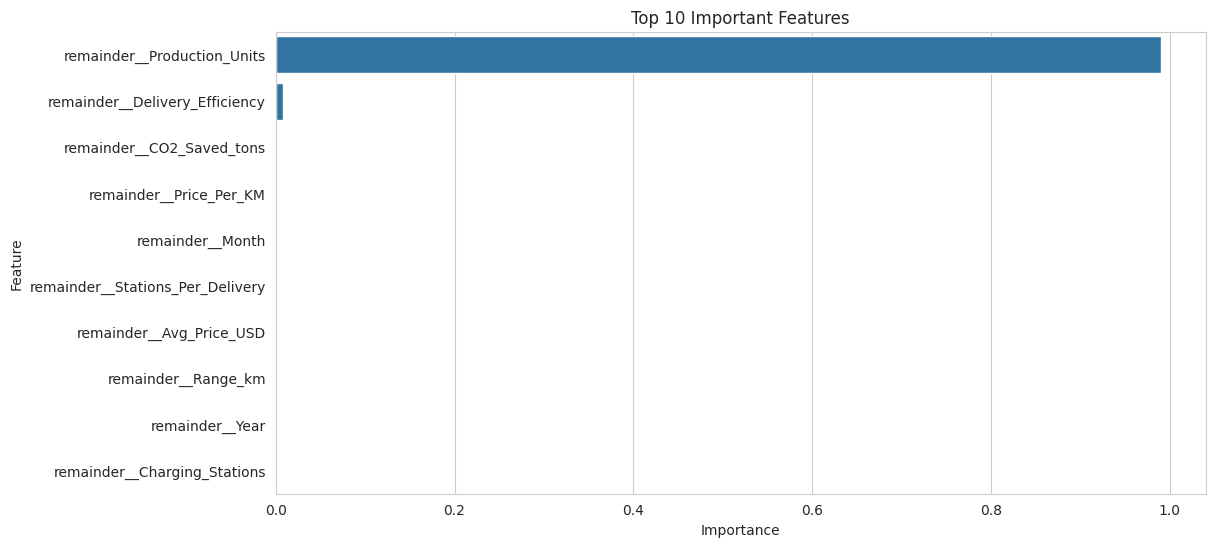

In [147]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df.head(10)
)

plt.title("Top 10 Important Features")

plt.show()